In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
from numpy import pi 
import numpy as np 
from scipy.interpolate import interp1d 

from funcshape.networks import CurveReparametrizer
from funcshape.layers.sineseries import SineSeries
from funcshape.loss import CurveDistance
from funcshape.logging import Logger
from funcshape.reparametrize import reparametrize
from funcshape.utils import col_linspace
from funcshape.visual import plot_curve 
from funcshape.testlib.curves import Circle, LogStepDiff, HalfCircle
from funcshape.transforms import SRVT
from funcshape.curve import Curve
from funcshape.functions import Function 

In [3]:
class CircleWithRadius(Curve):
    def __init__(self, r=1.0):
        self.r = r
        super().__init__(
            (lambda x: r*torch.cos(2 * pi * x), lambda x: r*torch.sin(2 * pi * x))
        )

    def derivative(self, X, h=None):
        return torch.cat(
            [-2 * pi * torch.sin(2 * pi * X) * self.r, +2 * pi * torch.cos(2 * pi * X)* self.r], dim=-1
        )

In [4]:
class Ellipse(Curve):
    def __init__(self, a=1.0, b=0.5, h=0.0, k=0.0, theta=0.0):
        """
        Rotated ellipse centered at (h, k) with semiaxes a, b, rotated by theta (degrees).
        Parametrized over x in [0,1].
        """
        self.a = torch.as_tensor(a, dtype=torch.float32)
        self.b = torch.as_tensor(b, dtype=torch.float32)
        self.h = torch.as_tensor(h, dtype=torch.float32)
        self.k = torch.as_tensor(k, dtype=torch.float32)
        # Convert degrees to radians, store as tensor
        self.theta = torch.tensor(theta * pi / 180.0, dtype=torch.float32)

        def xfun(X):
            t = 2 * pi * X
            return (
                self.h
                + self.a * torch.cos(t) * torch.cos(self.theta)
                - self.b * torch.sin(t) * torch.sin(self.theta)
            )

        def yfun(X):
            t = 2 * pi * X
            return (
                self.k
                + self.a * torch.cos(t) * torch.sin(self.theta)
                + self.b * torch.sin(t) * torch.cos(self.theta)
            )

        super().__init__((xfun, yfun))

    def derivative(self, X, h=None):
        """Derivative wrt parameter X ∈ [0,1]."""
        t = 2 * pi * X
        dt = 2 * pi

        dxdt = (
            -self.a * torch.sin(t) * torch.cos(self.theta)
            - self.b * torch.cos(t) * torch.sin(self.theta)
        )
        dydt = (
            -self.a * torch.sin(t) * torch.sin(self.theta)
            + self.b * torch.cos(t) * torch.cos(self.theta)
        )

        # Apply chain rule (dt/dX = 2π)
        dxdt *= dt
        dydt *= dt

        return torch.cat([dxdt, dydt], dim=-1)


In [5]:
class ParametricCurve(Curve):
    """
    Generic parametric curve.
    Takes evaluated points as input and returns a callable parametric curve.
    """
    def __init__(self, points: torch.Tensor):
        """
        points: Tensor of shape (N, D) where D is the dimension (e.g., 2 for 2D, 3 for 3D)
        """
        assert points.ndim == 2, "points must be a 2D tensor of shape (N, D)"
        self.points = points
        self.N, self.D = points.shape

        # Parameterization: t in [0,1]
        self.t_values = torch.linspace(0, 1, self.N)

        # Create an interpolation function for each dimension
        self.interpolators = {}
        points_np = points.numpy()
        t_np = self.t_values.numpy()
        coords = ["x", "y"]
        for d in range(self.D):
            self.interpolators[coords[d]] = interp1d(
                t_np, 
                points_np[:, d], 
                kind='cubic', 
                fill_value="extrapolate"
            )
        
        def xfun(t):
            t_np = t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.array(t)
            return (torch.tensor(self.interpolators["x"](t_np), dtype=torch.float32))

        def yfun(t):
            t_np = t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.array(t)
            return (torch.tensor(self.interpolators["y"](t_np), dtype=torch.float32))

        super().__init__((xfun, yfun))

    def derivative(self, t, h=1e-5):
        """
        Numerical derivative using central differences
        """
        t = torch.tensor(t, dtype=torch.float32) if not isinstance(t, torch.Tensor) else t
        t_plus = t + h
        t_minus = t - h
        f_plus = self(t_plus)
        f_minus = self(t_minus)
        return (f_plus - f_minus) / (2 * h)


In [6]:
# ref = Ellipse(theta=30.0, h=0.0, k=1.5)
g = LogStepDiff()
# query = Ellipse(theta=30.0)

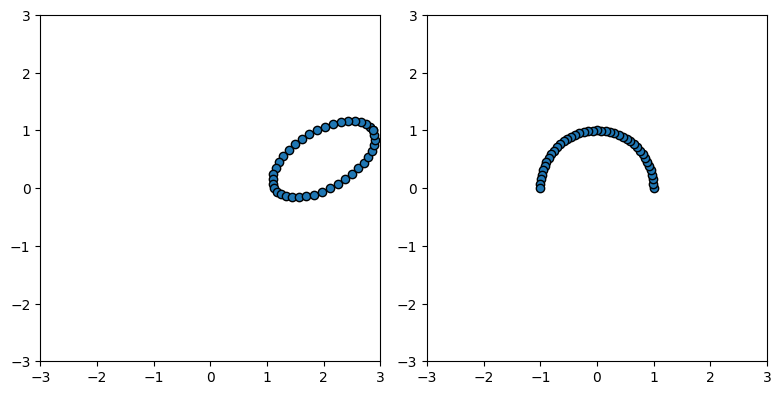

In [7]:
f = Ellipse(theta=30.0, h=2.0, k=0.5)
g = CircleWithRadius(r=1.0)
g = HalfCircle()
# g = Ellipse(theta=90.0, h=0.0, k=1.5)
x = col_linspace(0, 1, 25)
ref = ParametricCurve(f(x))
query = ParametricCurve(g(x))

# Plot curves
fig, axs = plt.subplots(1,2, figsize=(8, 4))
plot_curve(ref, npoints=100, dotpoints=41, ax=axs[0])
plot_curve(query, npoints=100, dotpoints=41, ax=axs[1])
plt.tight_layout()
for ax in axs:
    ax.set_xlim([-3.0, 3.0])
    ax.set_ylim([-3.0, 3.0])
plt.show()

[Iter     1] loss: 10.632409
[Iter     2] loss: 10.632409
Finished training in 0.07167s


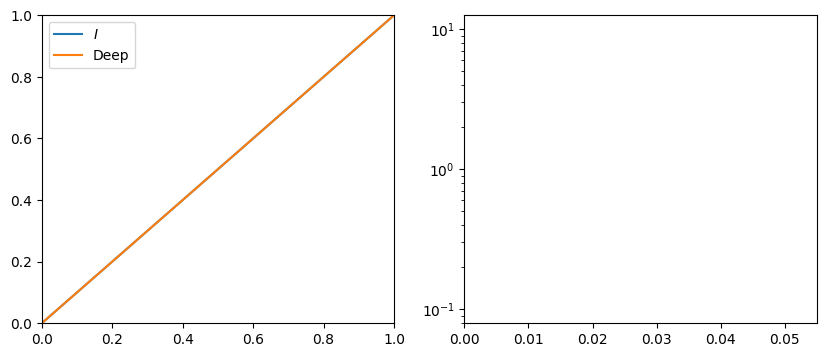

In [8]:
q = SRVT(query)
r = SRVT(ref)

n = 15  # Number of basis functions in layer
k = 1024  # Number of points used for evaluation.
ell = 10 # Number of layers used to approximate \phi
# Deep reparametrization
loss = CurveDistance(q, r, k=k)
RN = CurveReparametrizer([
    SineSeries(n) for _ in range(ell)
])
opt = torch.optim.LBFGS(
    RN.parameters(), 
    line_search_fn='strong_wolfe', 
    max_iter=300, 
    max_eval=300,
    history_size=300,
)
error_deep = reparametrize(RN, loss, opt, 300, Logger(1))
RN.detach()
x = col_linspace(0, 1, k)
y_deep = RN(x)

# Plot diffeomorphism and subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(x, x, label=r"$I$")
ax1.plot(x, y_deep, label="Deep")
# ax1.plot(x, g(x), 'k--', label=r'$ \varphi $')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.legend()
ax2.semilogy(error_deep / error_deep[0])
ax2.set_xlim(0, None)
plt.show()

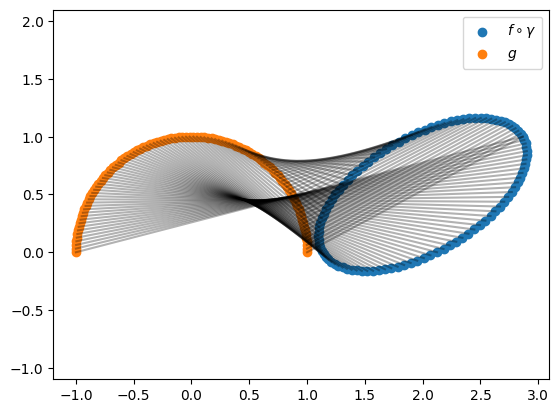

In [9]:
fig, ax = plt.subplots()
xlin = col_linspace(0, 1, 100)
ref_ = ref(RN(xlin))
query_ = query(xlin)
ax.scatter(ref_[:,0], ref_[:,1], label=r"$ f \circ \gamma$")
ax.scatter(query_[:,0], query_[:,1], label=r"$g$")
for p1, p2 in zip(ref_, query_):
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], "k-", alpha=0.3)
ax.legend()
ax.axis("equal")
plt.show()

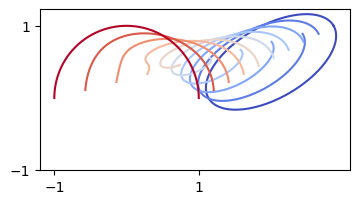

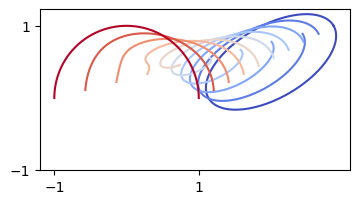

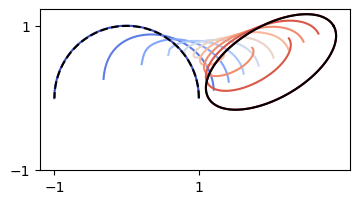

In [10]:
# Interpolate
from funcshape.interpolation import linear_interpolate, geodesic

numsteps=10
curves = linear_interpolate(ref, query, steps=numsteps)
curves_after = linear_interpolate(ref, query.compose(RN), steps=numsteps)
rafter = r.compose(RN)
srvts = geodesic(q, rafter, steps=numsteps)
colors = plt.get_cmap("coolwarm")(np.linspace(0,1,numsteps))

# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))
fig, ax1 = plt.subplots(1, 1, figsize=(4, 4))
[plot_curve(ci, ax=ax1, color=colori, npoints=601) for ci, colori in zip(curves, colors)]
ax1.set_aspect("equal")
ax1.set_xticks([-1, 1])
ax1.set_yticks([-1, 1])


fig, ax2 = plt.subplots(1, 1, figsize=(4, 4))
[plot_curve(ci, ax=ax2, color=colori, npoints=601) for ci, colori in zip(curves_after, colors)]
ax2.set_aspect("equal")
ax2.set_xticks([-1, 1])
ax2.set_yticks([-1, 1])


fig, ax3 = plt.subplots(1, 1, figsize=(4, 4))
starts = [(1.0-t)*query(torch.Tensor([0.0])) + t*ref(torch.Tensor([0.0])) for t in np.linspace(0,1, numsteps)]
[plot_curve(lambda x: ci(x)+start, ax=ax3, color=colori, npoints=601) for ci, colori, start in zip(srvts, colors, starts)]
plot_curve(ref, ax=ax3, color="k")
plot_curve(query, ax=ax3, color="k", ls='--')
ax3.set_aspect("equal")
ax3.set_xticks([-1, 1])
ax3.set_yticks([-1, 1])

plt.show()

In [11]:
dist2 = 0.0
for p1, p2 in zip(ref_, query_):
    dist2 += ((p1-p2)**2).sum()
distance = torch.sqrt(dist2/len(ref_)) 
print(f"Spatial distance between the two curves : {distance:.2f}")# should be the value of k

Spatial distance between the two curves : 2.39


In [12]:
def curvature_difference(R, a, b, t):
    """
    Compute the curvature difference Δκ(t) = κ_circle - κ_ellipse
    
    Parameters:
        R : float
            Radius of the circle
        a : float
            Semi-major axis of the ellipse
        b : float
            Semi-minor axis of the ellipse
        t : float or array-like
            Parametric angle (in radians)
    
    Returns:
        delta_kappa : float or np.ndarray
            Curvature difference at the given t
    """
    # Circle curvature
    kappa_c = 1 / R
    # Ellipse curvature
    kappa_e = (a * b) / ((a**2 * torch.sin(t)**2 + b**2 * torch.cos(t)**2)**(3/2))
    # Curvature difference
    delta_kappa = kappa_c - kappa_e
    return delta_kappa

delta_kappa_t = curvature_difference(g.r, f.a, f.b, xlin)
delta_kappa_mean = delta_kappa_t.mean()
print(f"Curvature difference between Ellipse and Circle : {delta_kappa_mean:.2f}")

AttributeError: 'HalfCircle' object has no attribute 'r'

In [ ]:
phi = Function(xlin.squeeze(), RN(xlin))

In [ ]:
def phase_distance(warping : Function)->torch.Tensor:
    """ Compute Phase distance between two functions given warping
    
    Parameters:
    =========== 
        warping : funcshape.functions.Function
            Warping function aligning f2 to f1        
            
    Returns:
    ===========
        dist : torch.Tensor
            Distance between the functions in the phase space
    """
    coordinates = (warping.x, )
    gam_dev = torch.gradient(warping.fx.squeeze(), spacing=coordinates)[0].abs()
    integrand = torch.sqrt(gam_dev).squeeze()
    theta = torch.trapezoid(integrand, x=warping.x)
    dist = torch.arccos(torch.clamp(theta, -1, 1))    

    return dist.to(warping.x.device)

In [ ]:
phase_distance(phi)

tensor(0.1597)